# 🛒 E-Commerce Data Analytics Using DummyJSON API

## Author
**Name:** Vansh Sharma  
**Role:** Data Analytics Enthusiast

---

## Project Overview

This project demonstrates an end-to-end **E-Commerce Data Analytics** workflow using the **DummyJSON REST API**. The data was collected from multiple API endpoints, cleaned, transformed, merged, and analyzed to extract meaningful business insights through KPIs and visualizations.

---

## Datasets Used

| Dataset | Rows | Columns |
|---------|-----:|--------:|
| Products | 194 | 16 |
| Users | 208 | 17 |
| Carts | 208 | 7 |

---

## Data Processing

- Retrieved data from **Products**, **Users**, and **Carts** APIs.
- Cleaned and preprocessed each dataset.
- Removed unnecessary columns.
- Converted nested cart product lists into individual rows using **`explode()`**.
- Created a new DataFrame named **`cart_items`**, where each row represents a single product purchased in a cart.
- Merged all datasets into a single DataFrame for business analysis.

---

## Final Dataset

| Description | Value |
|------------|------:|
| Rows | **800** |
| Columns | **42** |

### Why did the rows increase from **208** to **800**?

Each record in the original **Carts** dataset represents an entire shopping cart, where the **`products`** column contains a list of multiple products. After applying **`explode()`**, every product inside a cart becomes a separate row. This transformed the data from **cart-level** to **product-level**, increasing the total rows from **208** to **800** and enabling detailed product-wise and customer-wise analysis.

---

## Project Workflow

- API Data Collection
- Data Cleaning & Preprocessing
- Exploratory Data Analysis (EDA)
- KPI Generation
- Data Visualization
- Dataset Merging
- Business Insights

---

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Requests (REST API)
- Jupyter Notebook

# IMPORT LIBRARIES

In [26]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


#  LOAD DATASET 1 `products_df`

In [27]:


url = "https://dummyjson.com/products?limit=0"

response = requests.get(url)

products_data = response.json()

products_df = pd.DataFrame(products_data["products"])



# DATA CLEANING FOR `products_df`

In [28]:
products_df.columns


Index(['id', 'title', 'description', 'category', 'price', 'discountPercentage',
       'rating', 'stock', 'tags', 'brand', 'sku', 'weight', 'dimensions',
       'warrantyInformation', 'shippingInformation', 'availabilityStatus',
       'reviews', 'returnPolicy', 'minimumOrderQuantity', 'meta', 'images',
       'thumbnail'],
      dtype='str')

# REMOVE UNWANTED COLUMNS FROM `products_df`

In [29]:
products_data["products"]=products_df.drop(
    columns=["tags", "images", "reviews", "dimensions", "meta","thumbnail"],
    inplace=True,
    errors="ignore"
)

In [30]:
# ================= PRODUCTS DATASET OVERVIEW =================

print("="*70)
print("products_df.duplicated().sum()")
print("="*70)
print(products_df.duplicated().sum())
 
 

print("\n" + "="*70)
print("products_df.info()")
print("="*70)
products_df.info()   # Don't use print() with info()

print("\n" + "="*70)
print("products_df.shape")
print("="*70)
print(products_df.shape)

print("\n" + "="*70)
print("products_df.columns")
print("="*70)
print(products_df.columns)

print("\n" + "="*70)
print("products_df.describe()")
print("="*70)
print(products_df.describe())   # Add ()

print("\n" + "="*70)
print("products_df.isnull().sum()")
print("="*70)
print(products_df.isnull().sum())

products_df.duplicated().sum()
0

products_df.info()
<class 'pandas.DataFrame'>
RangeIndex: 194 entries, 0 to 193
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    194 non-null    int64  
 1   title                 194 non-null    str    
 2   description           194 non-null    str    
 3   category              194 non-null    str    
 4   price                 194 non-null    float64
 5   discountPercentage    194 non-null    float64
 6   rating                194 non-null    float64
 7   stock                 194 non-null    int64  
 8   brand                 102 non-null    str    
 9   sku                   194 non-null    str    
 10  weight                194 non-null    int64  
 11  warrantyInformation   194 non-null    str    
 12  shippingInformation   194 non-null    str    
 13  availabilityStatus    194 non-null    str    
 14  returnPolicy          194 non-nu

In [31]:
products_df.head()

,id,title,description,category,price,discountPercentage,rating,stock,brand,sku,weight,warrantyInformation,shippingInformation,availabilityStatus,returnPolicy,minimumOrderQuantity
0,1,Essence Mascara Lash Princess,The Essence Mascara Lash Princess is a popular...,beauty,9.99,10.48,2.56,99,Essence,BEA-ESS-ESS-001,4,1 week warranty,Ships in 3-5 business days,In Stock,No return policy,48
1,2,Eyeshadow Palette with Mirror,The Eyeshadow Palette with Mirror offers a ver...,beauty,19.99,18.19,2.86,34,Glamour Beauty,BEA-GLA-EYE-002,9,1 year warranty,Ships in 2 weeks,In Stock,7 days return policy,20
2,3,Powder Canister,The Powder Canister is a finely milled setting...,beauty,14.99,9.84,4.64,89,Velvet Touch,BEA-VEL-POW-003,8,3 months warranty,Ships in 1-2 business days,In Stock,No return policy,22
3,4,Red Lipstick,The Red Lipstick is a classic and bold choice ...,beauty,12.99,12.16,4.36,91,Chic Cosmetics,BEA-CHI-LIP-004,1,3 year warranty,Ships in 1 week,In Stock,7 days return policy,40
4,5,Red Nail Polish,The Red Nail Polish offers a rich and glossy r...,beauty,8.99,11.44,4.32,79,Nail Couture,BEA-NAI-NAI-005,8,1 month warranty,Ships overnight,In Stock,No return policy,22


# OVERVIEW `products_df` 


In [32]:
# products_df["id"].nunique()

print("="*70)
print("Unique Values in Each Column")
print("="*70)

for col in products_df.columns:
    print(f"{col} = {products_df[col].nunique()}")


Unique Values in Each Column
id = 194
title = 193
description = 194
category = 24
price = 76
discountPercentage = 186
rating = 138
stock = 86
brand = 63
sku = 194
weight = 10
warrantyInformation = 10
shippingInformation = 6
availabilityStatus = 3
returnPolicy = 5
minimumOrderQuantity = 44


In [33]:
print("="*70)
print("Value Counts for Each Column")
print("="*70)

for col in products_df.columns:
    print(f"\n{'='*70}")
    print(f"products_df['{col}'].value_counts()")
    print("="*70)
    print(products_df[col].value_counts(dropna=False))

Value Counts for Each Column

products_df['id'].value_counts()
id
1      1
2      1
3      1
4      1
5      1
      ..
190    1
191    1
192    1
193    1
194    1
Name: count, Length: 194, dtype: int64

products_df['title'].value_counts()
title
Rolex Cellini Moonphase          2
Essence Mascara Lash Princess    1
Eyeshadow Palette with Mirror    1
Powder Canister                  1
Red Lipstick                     1
                                ..
Red Shoes                        1
IWC Ingenieur Automatic Steel    1
Rolex Datejust Women             1
Watch Gold for Women             1
Women's Wrist Watch              1
Name: count, Length: 193, dtype: int64

products_df['description'].value_counts()
description
The Essence Mascara Lash Princess is a popular mascara known for its volumizing and lengthening effects. Achieve dramatic lashes with this long-lasting and cruelty-free formula.               1
The Eyeshadow Palette with Mirror offers a versatile range of eyeshadow shades f

In [34]:
print("="*70)
print("RATING VALUE COUNTS SUMMARY")
print("="*70)

rating_counts = products_df["rating"].value_counts()

print(f"Maximum Frequency = {rating_counts.max()}")
print(f"Minimum Frequency = {rating_counts.min()}")
print(f"Average Frequency = {rating_counts.mean():.2f}")



RATING VALUE COUNTS SUMMARY
Maximum Frequency = 4
Minimum Frequency = 1
Average Frequency = 1.41


In [35]:
print("="*70)
print("HIGHEST RATED PRODUCT")
print("="*70)
print(products_df.loc[products_df["rating"].idxmax(),
                      ["title", "brand", "category", "rating"]])

print("\n" + "="*70)
print("LOWEST RATED PRODUCT")
print("="*70)
print(products_df.loc[products_df["rating"].idxmin(),
                      ["title", "brand", "category", "rating"]])

HIGHEST RATED PRODUCT
title         Amazon Echo Plus
brand                   Amazon
category    mobile-accessories
rating                    4.99
Name: 98, dtype: object

LOWEST RATED PRODUCT
title          iPhone X
brand             Apple
category    smartphones
rating             2.51
Name: 123, dtype: object


In [99]:
# Average Order Value (AOV)
final_df.groupby("cart_id")["product_total"].sum().mean().round()


np.float64(18434.0)

# KPI FOR `products_df`

In [40]:
print("="*70)
print("PRODUCTS KPI")
print("="*70)

print(f"Total Products      = {products_df['id'].nunique()}")
print(f"Total Categories    = {products_df['category'].nunique()}")
print(f"Total Brands        = {products_df['brand'].nunique()}")
print(f"Average Price       = {products_df['price'].mean().round(2)}")
print(f"Highest Price       = {products_df['price'].max()}")
print(f"Lowest Price        = {products_df['price'].min()}")
print(f"Minimum Rating      = {products_df['rating'].min()}")
print(f"Average Rating      = {products_df['rating'].mean().round(2)}")
print(f"Average Discount %  = {products_df['discountPercentage'].mean().round(2)}")
print(f"Total Stock         = {products_df['stock'].sum()}")

PRODUCTS KPI
Total Products      = 194
Total Categories    = 24
Total Brands        = 63
Average Price       = 1570.1
Highest Price       = 36999.99
Lowest Price        = 0.79
Minimum Rating      = 2.51
Average Rating      = 3.8
Average Discount %  = 10.56
Total Stock         = 9779


# DATA VISUALIZATION FOR `products_df`

### Highest vs Lowest Rated Products

- Compares the top 10 highest-rated and lowest-rated products.
- Helps identify customer favorites and products that may need improvement.

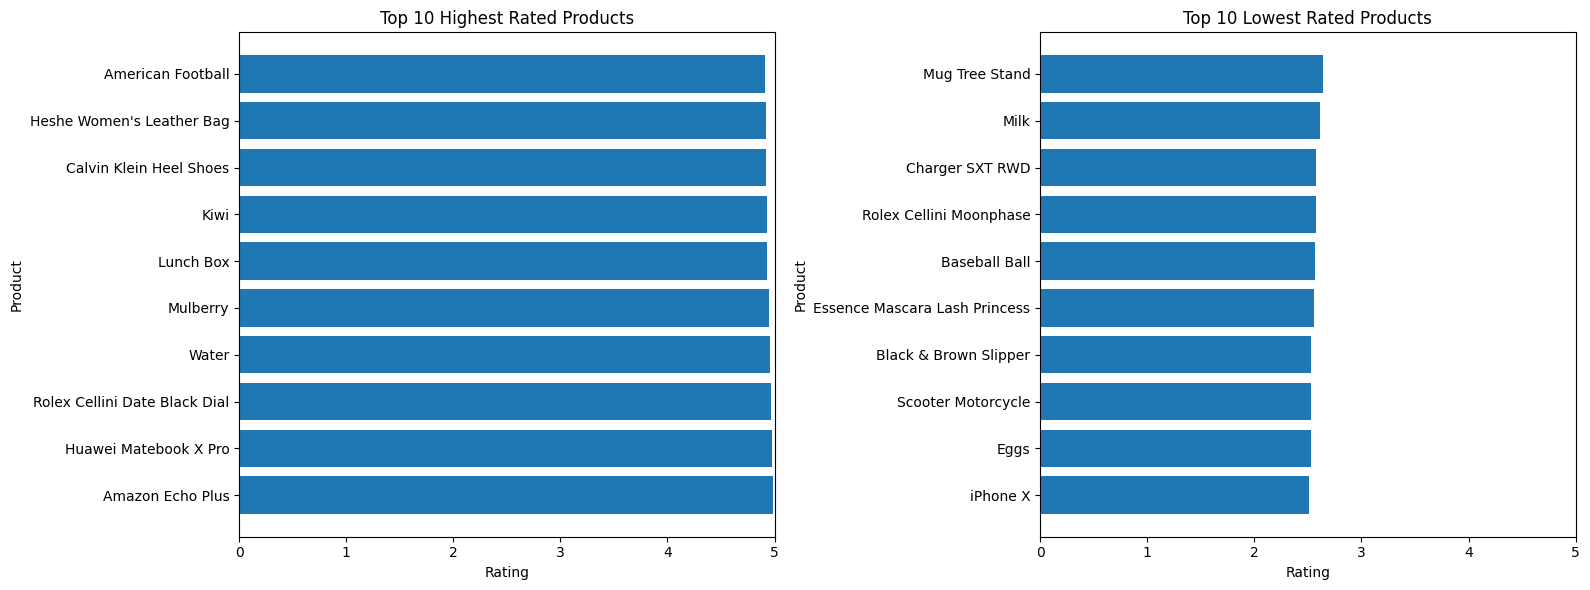

In [41]:
top_rated = (
    products_df[["title", "rating"]]
    .sort_values(by="rating", ascending=False)
    .head(10)
)

lowest_rated = (
    products_df[["title", "rating"]]
    .sort_values(by="rating", ascending=True)
    .head(10)
)

plt.figure(figsize=(16,6))

# Highest Rated
plt.subplot(1,2,1)
plt.barh(top_rated["title"], top_rated["rating"])
plt.title("Top 10 Highest Rated Products")
plt.xlabel("Rating")
plt.ylabel("Product")
plt.xlim(0,5)

# Lowest Rated
plt.subplot(1,2,2)
plt.barh(lowest_rated["title"], lowest_rated["rating"])
plt.title("Top 10 Lowest Rated Products")
plt.xlabel("Rating")
plt.ylabel("Product")
plt.xlim(0,5)

plt.tight_layout()
plt.show()

### Number of Products by Category

- Shows the number of products available in each category.
- Helps identify categories with the largest product offerings.

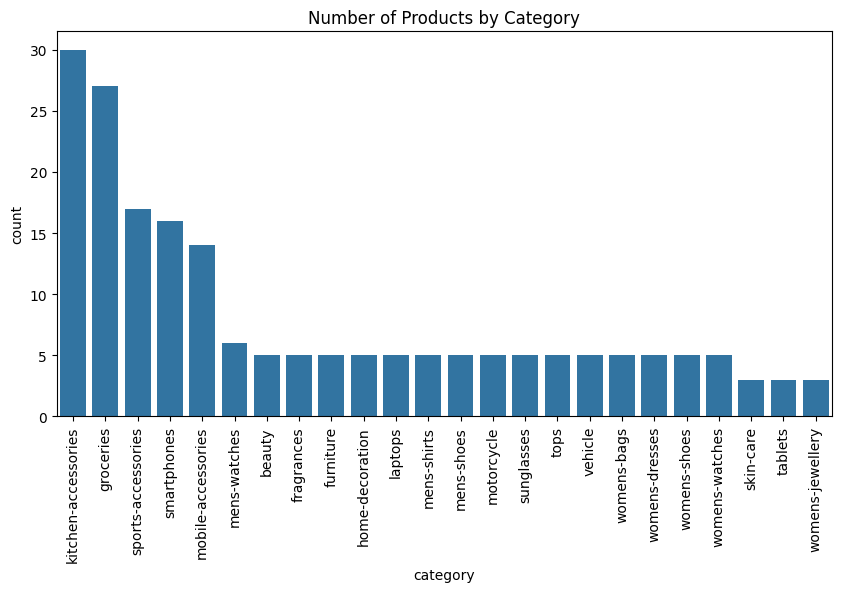

In [42]:
plt.figure(figsize=(10,5))
sns.countplot(data=products_df, x="category", order=products_df["category"].value_counts().index)
plt.xticks(rotation=90)
plt.title("Number of Products by Category")
plt.show()

### Top 10 Brands

- Displays the brands with the highest number of products.
- Helps identify the most represented brands in the product catalog.

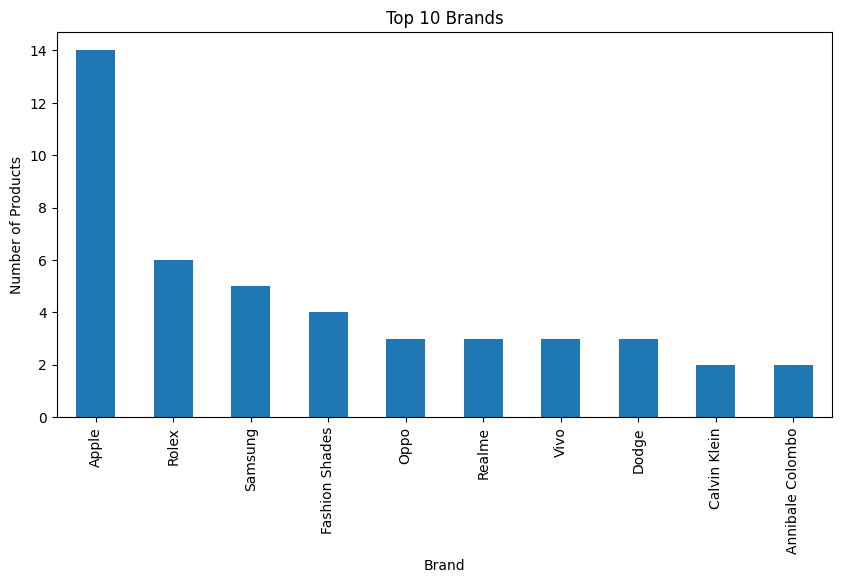

In [43]:
plt.figure(figsize=(10,5))

products_df["brand"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Products")
plt.show()

### Rating Distribution

- Shows how product ratings are distributed.
- Helps understand overall customer satisfaction.
```

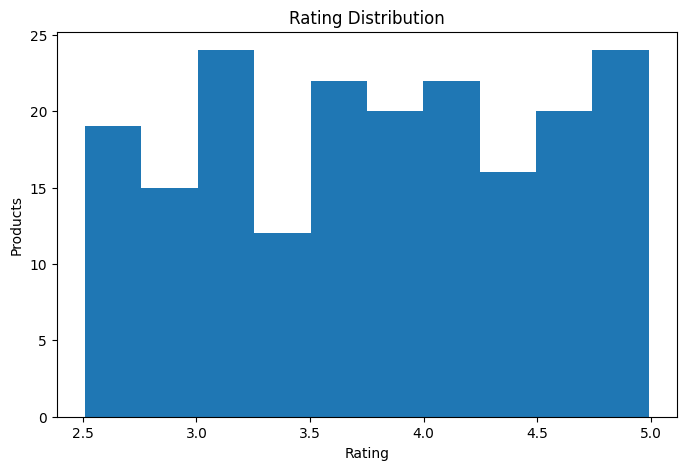

In [44]:
plt.figure(figsize=(8,5))

plt.hist(products_df["rating"], bins=10)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Products")
plt.show()

### Price vs Rating

- Shows the relationship between product price and customer rating.
- Helps identify whether higher-priced products receive better ratings.

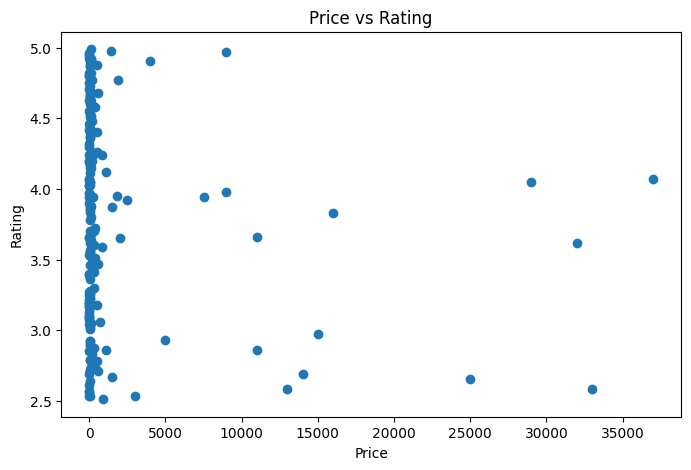

In [45]:
plt.figure(figsize=(8,5))

plt.scatter(products_df["price"], products_df["rating"])

plt.title("Price vs Rating")
plt.xlabel("Price")
plt.ylabel("Rating")
plt.show()

### Average Price by Category

- Shows the average price of products in each category.
- Helps compare pricing across different product categories.

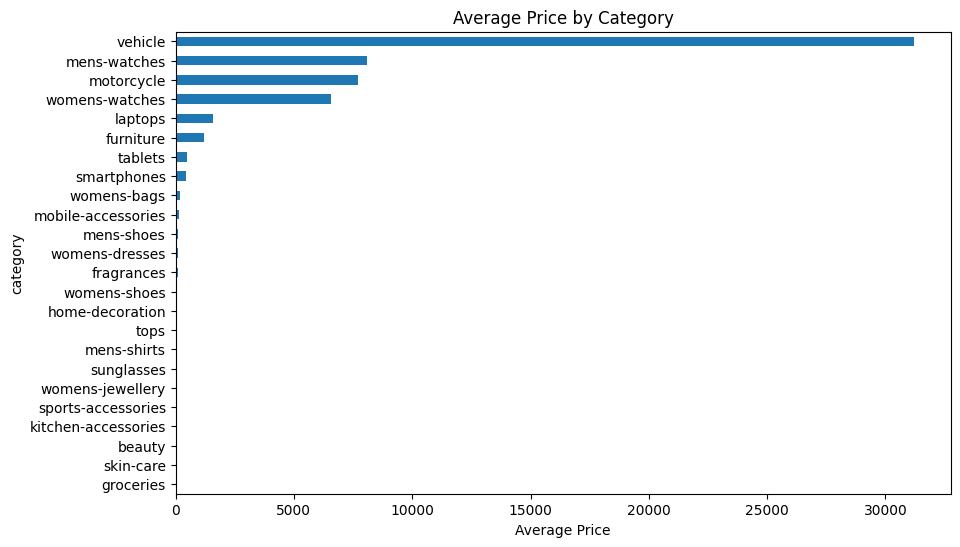

In [46]:
AVG_PRICE = (
    products_df
    .groupby("category")["price"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

AVG_PRICE.plot(kind="barh")

plt.title("Average Price by Category")
plt.xlabel("Average Price")
plt.show()

### Correlation Heatmap

- Shows the relationship between numerical features.
- Helps identify positive, negative, or weak correlations in the dataset.
```

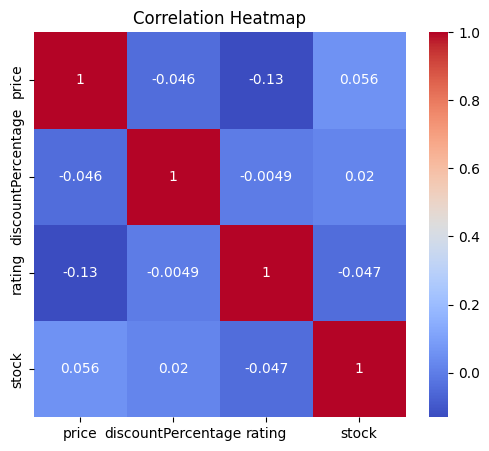

In [47]:
plt.figure(figsize=(6,5))

sns.heatmap(
    products_df[["price","discountPercentage","rating","stock"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# LAOD DATASET 2 user_df

In [48]:
url = "https://dummyjson.com/users?limit=0"

response = requests.get(url)

users_data = response.json()

users_df = pd.DataFrame(users_data["users"])


# DATA CLEANING FOR`users_df`


In [49]:
users_data =users_df.drop(
    columns=[
        "password",
        "image",
        "hair",
        "ip",
        "macAddress",
        "bank",
        "crypto",
        "ssn",
        "ein",
        "userAgent",
        "address",
        "company",
        "eyeColor",
        "bloodGroup",
        "birthDate",
        "maidenName"
    ],
    inplace=True,
    errors="ignore"
)

In [50]:
users_df.columns

Index(['id', 'firstName', 'lastName', 'age', 'gender', 'email', 'phone',
       'username', 'height', 'weight', 'university', 'role'],
      dtype='str')

In [51]:
users_df.head()

,id,firstName,lastName,age,gender,email,phone,username,height,weight,university,role
0,1,Emily,Johnson,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,193.24,63.16,University of Wisconsin--Madison,admin
1,2,Michael,Williams,36,male,michael.williams@x.dummyjson.com,+49 258-627-6644,michaelw,186.22,76.32,Ohio State University,admin
2,3,Sophia,Brown,43,female,sophia.brown@x.dummyjson.com,+81 210-652-2785,sophiab,177.72,52.60,Pepperdine University,admin
3,4,James,Davis,46,male,james.davis@x.dummyjson.com,+49 614-958-9364,jamesd,193.31,62.10,University of Southern California,admin
4,5,Emma,Miller,31,female,emma.miller@x.dummyjson.com,+91 759-776-1614,emmaj,192.80,63.62,Northeastern University,admin


# DATASET OVERVIEW `users_df`

In [52]:
 # ================= USERS DATASET OVERVIEW =================

print("="*70)
print("users_df.duplicated().sum()")
print("="*70)
print(users_df.duplicated().sum())

print("\n" + "="*70)
print("users_df.head()")
print("="*70)
print(users_df.head())

print("\n" + "="*70)
print("users_df.info()")
print("="*70)
users_df.info()   # Don't use print() with info()

print("\n" + "="*70)
print("users_df.shape")
print("="*70)
print(users_df.shape)

print("\n" + "="*70)
print("users_df.columns")
print("="*70)
print(users_df.columns)

print("\n" + "="*70)
print("users_df.describe()")
print("="*70)
print(users_df.describe())

print("\n" + "="*70)
print("users_df.isnull().sum()")
print("="*70)
print(users_df.isnull().sum())

users_df.duplicated().sum()
0

users_df.head()
   id firstName  lastName  age  gender                             email  \
0   1     Emily   Johnson   29  female     emily.johnson@x.dummyjson.com   
1   2   Michael  Williams   36    male  michael.williams@x.dummyjson.com   
2   3    Sophia     Brown   43  female      sophia.brown@x.dummyjson.com   
3   4     James     Davis   46    male       james.davis@x.dummyjson.com   
4   5      Emma    Miller   31  female       emma.miller@x.dummyjson.com   

              phone  username  height  weight  \
0  +81 965-431-3024    emilys  193.24   63.16   
1  +49 258-627-6644  michaelw  186.22   76.32   
2  +81 210-652-2785   sophiab  177.72   52.60   
3  +49 614-958-9364    jamesd  193.31   62.10   
4  +91 759-776-1614     emmaj  192.80   63.62   

                          university   role  
0   University of Wisconsin--Madison  admin  
1              Ohio State University  admin  
2              Pepperdine University  admin  
3  University of 

# CHECK UNIQUE VALUES

In [53]:
print("\n" + "="*70)
print("Unique Values in Each Column")
print("="*70)

for col in users_df.columns:
    print(f"{col:<30} = {users_df[col].nunique()}")


Unique Values in Each Column
id                             = 208
firstName                      = 119
lastName                       = 117
age                            = 24
gender                         = 2
email                          = 208
phone                          = 208
username                       = 208
height                         = 203
weight                         = 205
university                     = 49
role                           = 3


# CHECK TOTAL COUNT

In [54]:
print("\n" + "="*70)
print("Value Counts")
print("="*70)

for col in users_df.columns:
    print(f"\n{'='*70}")
    print(f"users_df['{col}'].value_counts()")
    print("="*70)
    print(users_df[col].value_counts(dropna=False))


Value Counts

users_df['id'].value_counts()
id
1      1
2      1
3      1
4      1
5      1
      ..
204    1
205    1
206    1
207    1
208    1
Name: count, Length: 208, dtype: int64

users_df['firstName'].value_counts()
firstName
Avery      4
Harper     4
Gabriel    4
Aria       4
Lucas      4
          ..
Vivian     1
Adrian     1
Maya       1
Nova       1
Jace       1
Name: count, Length: 119, dtype: int64

users_df['lastName'].value_counts()
lastName
Perez       6
Gonzalez    5
Wright      5
Martinez    4
Garcia      4
           ..
Ross        1
Price       1
Young       1
Ramirez     1
Nelson      1
Name: count, Length: 117, dtype: int64

users_df['age'].value_counts()
age
30    19
29    17
27    17
28    16
32    16
34    15
31    14
35    12
33    11
37     9
42     8
36     7
26     7
43     5
46     5
38     5
45     5
39     4
25     4
40     4
44     4
41     2
23     1
24     1
Name: count, dtype: int64

users_df['gender'].value_counts()
gender
female    106
male      1

In [98]:
top_users = (
    final_df.groupby(["firstName", "lastName"])["product_total"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("="*70)
print("TOP 10 USERS BY SPENDING")
print("="*70)
print(top_users)

TOP 10 USERS BY SPENDING
firstName  lastName 
Addison    Wright       186110.85
Miles      Stevenson    154490.76
Dylan      Wells        150061.36
Grace      Perry        134382.82
Lincoln    Kelly        132262.29
Nicholas   Edwards      131224.81
Carter     Baker        129057.77
Logan      Torres       128999.90
Eleanor    Tyler        128964.87
Maya       Reed         128096.37
Name: product_total, dtype: float64


# KPI FOR `user_df`

In [56]:
print("="*70)
print("USERS KPI")
print("="*70)

print(f"Total Users           = {users_df['id'].nunique()}")
print(f"Male Users            = {(users_df['gender'] == 'male').sum()}")
print(f"Female Users          = {(users_df['gender'] == 'female').sum()}")

print(f"Average Age           = {users_df['age'].mean().round(2)} Years")
print(f"Youngest User Age     = {users_df['age'].min()} Years")
print(f"Oldest User Age       = {users_df['age'].max()} Years")

print(f"Average Height        = {users_df['height'].mean().round(2)} cm")
print(f"Average Weight        = {users_df['weight'].mean().round(2)} kg")

print(f"Total Universities    = {users_df['university'].nunique()}")
print(f"Total User Roles      = {users_df['role'].nunique()}")
 

USERS KPI
Total Users           = 208
Male Users            = 102
Female Users          = 106
Average Age           = 33.14 Years
Youngest User Age     = 23 Years
Oldest User Age       = 46 Years
Average Height        = 175.72 cm
Average Weight        = 75.04 kg
Total Universities    = 49
Total User Roles      = 3


# DATA VISUALIZATION FOR `users_df`

### Gender Distribution

- Shows the number of male and female users.
- Helps understand the gender composition of the customer base.

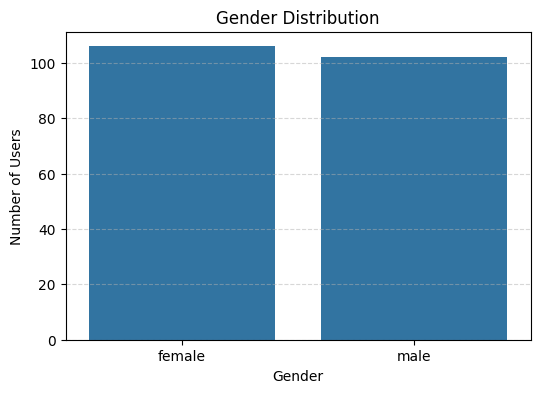

In [57]:
plt.figure(figsize=(6,4))

sns.countplot(data=users_df, x="gender")

plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Number of Users")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Age Distribution

- Shows how users are distributed across different age groups.
- Helps identify the most common customer age range.

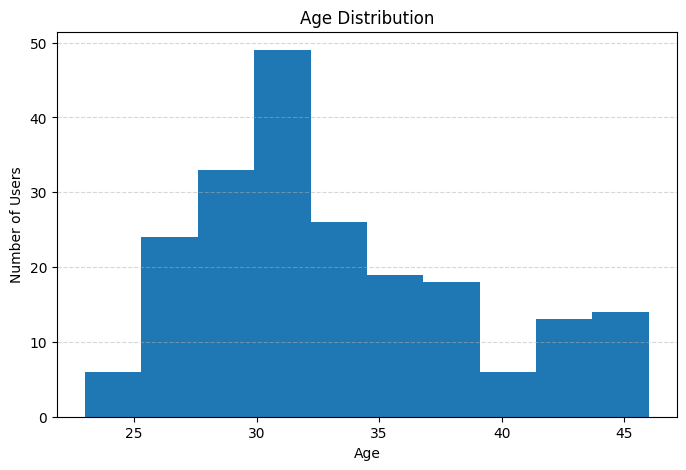

In [58]:
plt.figure(figsize=(8,5))

plt.hist(users_df["age"], bins=10)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Top 10 Universities

- Displays the universities with the highest number of users.
- Helps understand the educational background of the user base.

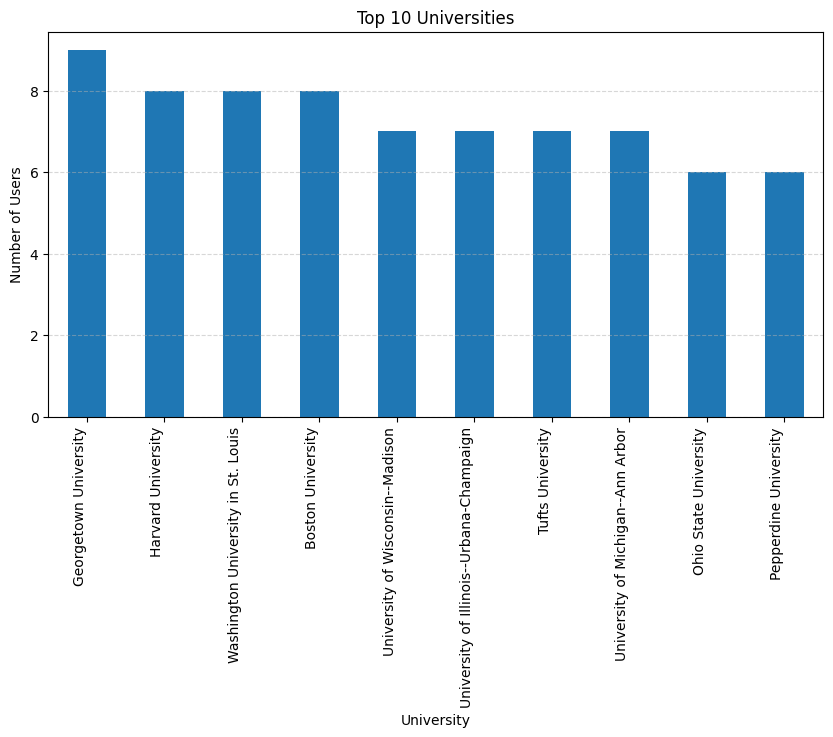

In [59]:
plt.figure(figsize=(10,5))

users_df["university"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Universities")
plt.xlabel("University")
plt.ylabel("Number of Users")
plt.xticks(rotation=90, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### User Role Distribution

- Shows the proportion of users across different roles.
- Helps understand the composition of the user base by role.

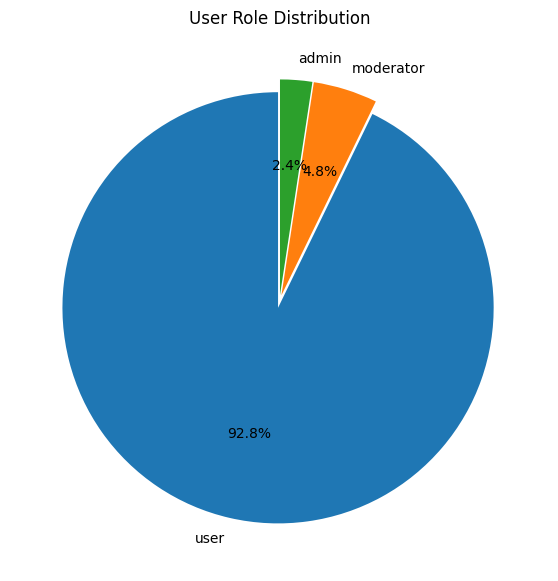

In [60]:
plt.figure(figsize=(7,7))

users_df["role"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90,
    explode=[0.03, 0.03, 0.03]
)

plt.title("User Role Distribution")
plt.ylabel("")

plt.show()

# LAOD DATASET 3 `carts_df`


In [61]:
url = "https://dummyjson.com/carts?limit=0"

response = requests.get(url)

carts_data = response.json()

carts_df = pd.DataFrame(carts_data["carts"])

carts_df.head()

,id,products,total,discountedTotal,userId,totalProducts,totalQuantity
0,1,"[{'id': 162, 'title': 'Blue Frock', 'price': 2...",13037.88,11510.81,1,4,12
1,2,"[{'id': 86, 'title': 'Man Short Sleeve Shirt',...",139.93,125.70,2,2,7
2,3,"[{'id': 24, 'title': 'Fish Steak', 'price': 14...",1794.85,1625.77,3,6,15
3,4,"[{'id': 92, 'title': 'Sports Sneakers Off Whit...",689.93,636.81,4,2,7
4,5,"[{'id': 161, 'title': 'Samsung Galaxy Tab Whit...",1467.88,1205.80,5,3,12


# DATASET OVERVIEW `carts_df`

In [62]:
# ================= CARTS DATASET OVERVIEW =================
print("="*70)
print("carts_df.duplicated().sum()")
print("="*70)
# print(carts_df.duplicated().sum()) # we can,t acess
 
print("\n" + "="*70)
print("carts_df.info()")
print("="*70)
carts_df.info()

print("\n" + "="*70)
print("carts_df.shape")
print("="*70)
print(carts_df.shape)

print("\n" + "="*70)
print("carts_df.columns")
print("="*70)
print(carts_df.columns)

print("\n" + "="*70)
print("carts_df.describe()")
print("="*70)
print(carts_df.describe())

print("\n" + "="*70)
print("carts_df.isnull().sum()")
print("="*70)
print(carts_df.isnull().sum())

carts_df.duplicated().sum()

carts_df.info()
<class 'pandas.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               208 non-null    int64  
 1   products         208 non-null    object 
 2   total            208 non-null    float64
 3   discountedTotal  208 non-null    float64
 4   userId           208 non-null    int64  
 5   totalProducts    208 non-null    int64  
 6   totalQuantity    208 non-null    int64  
dtypes: float64(2), int64(4), object(1)
memory usage: 11.5+ KB

carts_df.shape
(208, 7)

carts_df.columns
Index(['id', 'products', 'total', 'discountedTotal', 'userId', 'totalProducts',
       'totalQuantity'],
      dtype='str')

carts_df.describe()
               id          total  discountedTotal      userId  totalProducts  \
count  208.000000     208.000000       208.000000  208.000000     208.000000   
mean   104.500000   18434.031875     

# CHECK UNIQUE VALUES


In [63]:
print("\n" + "="*70)
print("Unique Values in Each Column")
print("="*70)

for col in carts_df.columns:
    try:
        print(f"{col:<30} = {carts_df[col].nunique()}")
    except TypeError:
        print(f"{col:<30} = Nested List (Skipped)")


Unique Values in Each Column
id                             = 208
products                       = Nested List (Skipped)
total                          = 207
discountedTotal                = 208
userId                         = 208
totalProducts                  = 5
totalQuantity                  = 24


# KPI FOR `carts_user`

In [64]:
print("="*70)
print("🛒 CARTS KPI")
print("="*70)

print(f"Total Carts              = {carts_df['id'].nunique()}")
print(f"Total Customers          = {carts_df['userId'].nunique()}")
print(f"Total Revenue            = {carts_df['total'].sum():.2f}")
print(f"Total Discounted Revenue = {carts_df['discountedTotal'].sum():.2f}")
print(f"Average Cart Value       = {carts_df['total'].mean().round(2)}")
print(f"Average Discounted Value = {carts_df['discountedTotal'].mean().round(2)}")
print(f"Total Products in Carts  = {carts_df['totalProducts'].sum()}")
print(f"Total Quantity           = {carts_df['totalQuantity'].sum()}")

🛒 CARTS KPI
Total Carts              = 208
Total Customers          = 208
Total Revenue            = 3834278.63
Total Discounted Revenue = 3456709.58
Average Cart Value       = 18434.03
Average Discounted Value = 16618.8
Total Products in Carts  = 800
Total Quantity           = 2417


# DATA VISUALIZATION FOR `carts_df`

### Cart Value Distribution

- Shows the distribution of cart values across all orders.
- Helps identify common purchase amounts and high-value carts.

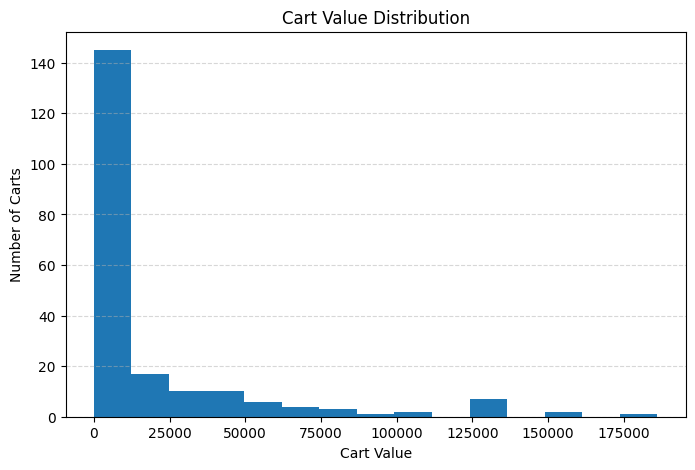

In [65]:
plt.figure(figsize=(8,5))

plt.hist(carts_df["total"], bins=15)

plt.title("Cart Value Distribution")
plt.xlabel("Cart Value")
plt.ylabel("Number of Carts")

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()

### Products per Cart

- Shows how many products customers purchase in each cart.
- Helps understand customer buying behavior and order size.

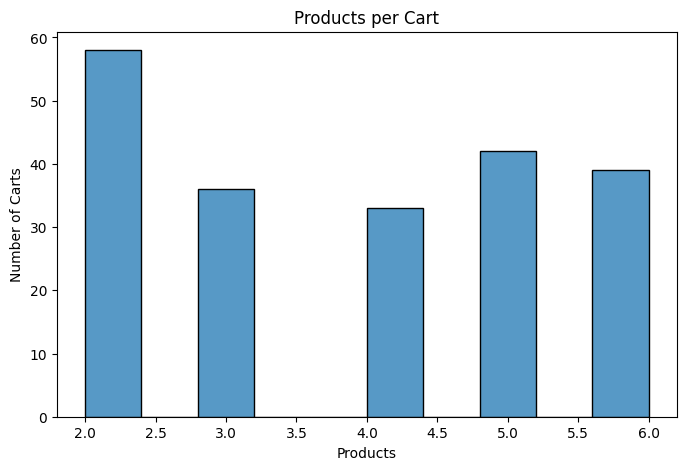

In [66]:
plt.figure(figsize=(8,5))

sns.histplot(carts_df["totalProducts"], bins=10)

plt.title("Products per Cart")
plt.xlabel("Products")
plt.ylabel("Number of Carts")

plt.show()

### Quantity per Cart

- Shows the total quantity of items purchased in each cart.
- Helps analyze customer purchasing volume and buying patterns.

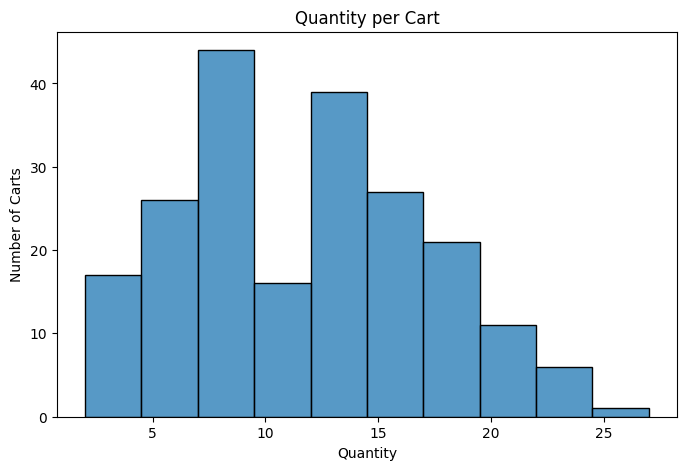

In [67]:
plt.figure(figsize=(8,5))

sns.histplot(carts_df["totalQuantity"], bins=10)

plt.title("Quantity per Cart")
plt.xlabel("Quantity")
plt.ylabel("Number of Carts")

plt.show()

### Quantity vs Revenue

- Shows the relationship between purchased quantity and cart revenue.
- Helps identify whether larger orders generate higher revenue.

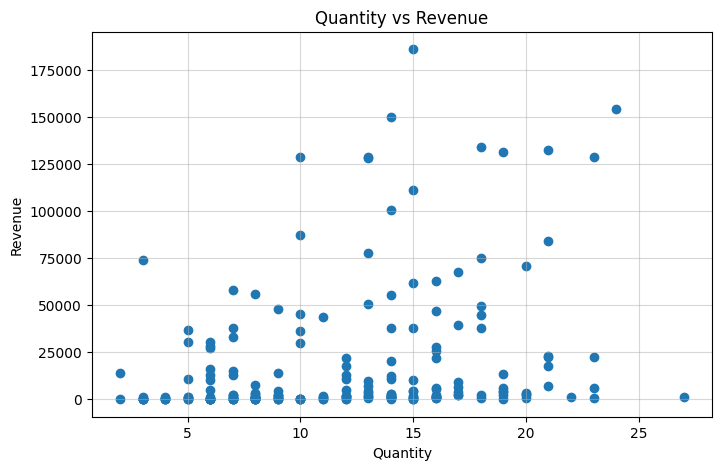

In [68]:
plt.figure(figsize=(8,5))

plt.scatter(
    carts_df["totalQuantity"],
    carts_df["total"]
)

plt.title("Quantity vs Revenue")
plt.xlabel("Quantity")
plt.ylabel("Revenue")

plt.grid(alpha=0.5)

plt.show()

### Total vs Discounted Total

- Compares the original cart value with the discounted value.
- Helps evaluate the impact of discounts on customer purchases.

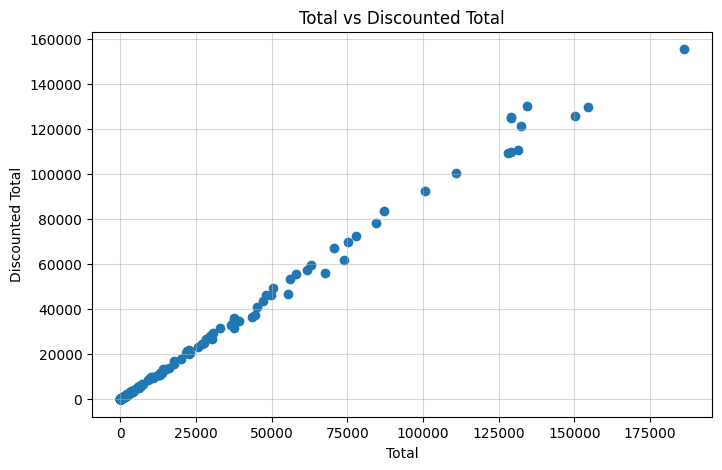

In [69]:
plt.figure(figsize=(8,5))

plt.scatter(
    carts_df["total"],
    carts_df["discountedTotal"]
)

plt.title("Total vs Discounted Total")
plt.xlabel("Total")
plt.ylabel("Discounted Total")

plt.grid(alpha=0.5)

plt.show()

## CONVERTING `carts_df` to `cart_items`

The original `carts_df` stored multiple products as a **list** in the `products` column. Using `explode()`, each product was converted into a separate row and its details were expanded into individual columns. The resulting DataFrame, **`cart_items`**, contains **one product per row**, making it suitable for merging, analysis, and visualization.

In [70]:
cart_items = carts_df.explode("products").reset_index(drop=True)

product_details = pd.json_normalize(cart_items["products"])

cart_items = cart_items.drop(columns=["products"])

cart_items = pd.concat([cart_items, product_details], axis=1)

cart_items.head()

,id,total,discountedTotal,userId,totalProducts,totalQuantity,id,title,price,quantity,total,discountPercentage,discountedTotal,thumbnail
0,1,13037.88,11510.81,1,4,12,162,Blue Frock,29.99,4,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...
1,1,13037.88,11510.81,1,4,12,113,Generic Motorcycle,3999.99,3,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...
2,1,13037.88,11510.81,1,4,12,122,iPhone 6,299.99,3,899.97,6.69,839.76,https://cdn.dummyjson.com/product-images/smart...
3,1,13037.88,11510.81,1,4,12,138,Baseball Ball,8.99,2,17.98,1.71,17.67,https://cdn.dummyjson.com/product-images/sport...
4,2,139.93,125.70,2,2,7,86,Man Short Sleeve Shirt,19.99,5,99.95,6.83,93.12,https://cdn.dummyjson.com/product-images/mens-...


The `products` column contains a list of dictionaries, where each dictionary represents a product. These nested values were extracted into separate columns such as `product_id`, `product_title`, `product_price`, and `product_quantity`, making the data suitable for analysis and merging.

In [71]:
cart_items.columns = [
    "cart_id",
    "cart_total",
    "cart_discounted_total",
    "userId",
    "cart_total_products",
    "cart_total_quantity",
    "product_id",
    "product_title",
    "product_price",
    "product_quantity",
    "product_total",
    "discount_percentage",
    "product_discounted_total",
    "thumbnail"
]

# MERGE `products_df` and `cart_items`

 

In [72]:
cart_products = pd.merge(
    cart_items,
    products_df,
    left_on="product_id",
    right_on="id",
    how="left"
)

# MERGE `cart_products` and `users_df`

In [73]:
final_df = pd.merge(
    cart_products,
    users_df,
    left_on="userId",
    right_on="id",
    how="left",
    suffixes=("_product", "_user")
)

In [74]:
# ================= FINAL DATASET OVERVIEW =================

print(final_df.shape)

print("="*70)
print(final_df.head())

print("="*70)
print(final_df.info())

print("="*70)
print(final_df.columns)

(800, 42)
   cart_id  cart_total  cart_discounted_total  userId  cart_total_products  \
0        1    13037.88               11510.81       1                    4   
1        1    13037.88               11510.81       1                    4   
2        1    13037.88               11510.81       1                    4   
3        1    13037.88               11510.81       1                    4   
4        2      139.93                 125.70       2                    2   

   cart_total_quantity  product_id           product_title  product_price  \
0                   12         162              Blue Frock          29.99   
1                   12         113      Generic Motorcycle        3999.99   
2                   12         122                iPhone 6         299.99   
3                   12         138           Baseball Ball           8.99   
4                    7          86  Man Short Sleeve Shirt          19.99   

   product_quantity  ...  lastName  age  gender  \
0      

# REMOVE UNWANTED COLUMNS FROM `final_df`

In [75]:
final_df.drop(
    columns=[
        "product_title",
        "product_price",
        "id_product",
        "id_user"
    ],
    inplace=True
)

# RENAME UNWANTED COLUMS FROM `final_df`

In [76]:
final_df.rename(
    columns={
        "title": "product_name",
        "price": "product_price",
        "userId": "user_id",
    },
    inplace=True
)

In [97]:
pd.set_option("display.max_columns", None) #---> THIS FOR SHOW ALL COLUMN NO LIMIT 
final_df.head(2)

,cart_id,cart_total,cart_discounted_total,user_id,cart_total_products,cart_total_quantity,product_id,product_quantity,product_total,discount_percentage,product_discounted_total,thumbnail,product_name,description,category,product_price,discountPercentage,rating,stock,brand,sku,weight_product,warrantyInformation,shippingInformation,availabilityStatus,returnPolicy,minimumOrderQuantity,firstName,lastName,age,gender,email,phone,username,height,weight_user,university,role
0,1,13037.88,11510.81,1,4,12,162,4,119.96,12.13,105.41,https://cdn.dummyjson.com/product-images/tops/...,Blue Frock,The Blue Frock is a charming and stylish dress...,tops,29.99,12.13,4.17,52,NaN,TOP-BRD-BLU-162,5,Lifetime warranty,Ships in 2 weeks,In Stock,60 days return policy,4,Emily,Johnson,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,193.24,63.16,University of Wisconsin--Madison,admin
1,1,13037.88,11510.81,1,4,12,113,3,11999.97,12.10,10547.97,https://cdn.dummyjson.com/product-images/motor...,Generic Motorcycle,The Generic Motorcycle is a versatile and reli...,motorcycle,3999.99,12.10,4.91,34,Generic Motors,MOT-GEN-GEN-113,8,1 year warranty,Ships in 2 weeks,In Stock,7 days return policy,1,Emily,Johnson,29,female,emily.johnson@x.dummyjson.com,+81 965-431-3024,emilys,193.24,63.16,University of Wisconsin--Madison,admin


# `final_df` IS FINAL DATASET AFTER MERGE ALL 3 TABELS

In [78]:
final_df.shape

(800, 38)

https://chatgpt.com/share/6a5e8fa1-87a8-83ee-872c-0f2dded2361f

In [96]:
final_df.value_counts().head(1)


cart_id  cart_total  cart_discounted_total  user_id  cart_total_products  cart_total_quantity  product_id  product_quantity  product_total  discount_percentage  product_discounted_total  thumbnail                                                                                           product_name             description                                                                                                                                                         category            product_price  discountPercentage  rating  stock  brand         sku              weight_product  warrantyInformation  shippingInformation  availabilityStatus  returnPolicy           minimumOrderQuantity  firstName  lastName  age  gender  email                         phone             username  height  weight_user  university            role
38       409.95      334.61                 38       3                    5                    110         2                 29.98          19.4                

In [80]:
final_df.nunique()

cart_id                     208
cart_total                  207
cart_discounted_total       208
user_id                     208
cart_total_products           5
cart_total_quantity          24
product_id                  189
product_quantity              5
product_total               276
discount_percentage         181
product_discounted_total    538
thumbnail                   189
product_name                188
description                 189
category                     24
product_price                75
discountPercentage          181
rating                      135
stock                        85
brand                        63
sku                         189
weight_product               10
warrantyInformation          10
shippingInformation           6
availabilityStatus            3
returnPolicy                  5
minimumOrderQuantity         44
firstName                   119
lastName                    117
age                          24
gender                        2
email   

## Cart and Product Relationship

In the original dataset, each `cart_id` contains multiple products stored together as a list.

Example (Before Flattening):

| cart_id | products |
|---------|----------|
| 193 | [product1, product2, product3, product4, product5, product6] |

Here, one cart has multiple products inside a single row.

After applying **explode/flattening**, each product gets its own row:

| cart_id | product |
|---------|---------|
| 193 | product1 |
| 193 | product2 |
| 193 | product3 |
| 193 | product4 |
| 193 | product5 |
| 193 | product6 |

This converts the data into a **product-level transactional format**, where each row represents one product inside a cart.

This structure helps in performing detailed e-commerce analysis such as:
- Top-selling products
- Category-wise sales analysis
- Revenue calculation
- Product performance analysis
- Customer purchasing behavior

In [81]:
print(final_df["cart_id"].value_counts())
print("="*60)

cart_id
3      6
7      6
8      6
12     6
28     6
      ..
190    2
199    2
203    2
205    2
208    2
Name: count, Length: 208, dtype: int64


# "E-COMMERCE BUSINESS KPI"

In [82]:
print("="*70)
print("E-COMMERCE BUSINESS KPI")
print("="*70)

print(f"Total Revenue              = ${final_df['product_total'].sum():,.2f}")

print(f"Total Orders               = {final_df['cart_id'].nunique()}")

print(f"Total Customers            = {final_df['user_id'].nunique()}")

print(f"Total Products Sold        = {final_df['product_quantity'].sum()}")

print(f"Total Categories           = {final_df['category'].nunique()}")

print(f"Total Brands               = {final_df['brand'].nunique()}")

print(f"Average Order Value (AOV)  = ${final_df.groupby('cart_id')['product_total'].sum().mean():.2f}")

print(f"Average Product Rating     = {final_df['rating'].mean():.2f}")

print(f"Average Discount (%)       = {final_df['discount_percentage'].mean():.2f}%")
print("="*70)


E-COMMERCE BUSINESS KPI
Total Revenue              = $3,834,278.63
Total Orders               = 208
Total Customers            = 208
Total Products Sold        = 2417
Total Categories           = 24
Total Brands               = 63
Average Order Value (AOV)  = $18434.03
Average Product Rating     = 3.78
Average Discount (%)       = 10.60%


### Revenue by Category

- This chart shows the total revenue generated by each product category.
- It helps identify the highest and lowest revenue-generating categories.
- Businesses can use this insight to focus marketing, inventory, and promotional efforts on high-performing categories.

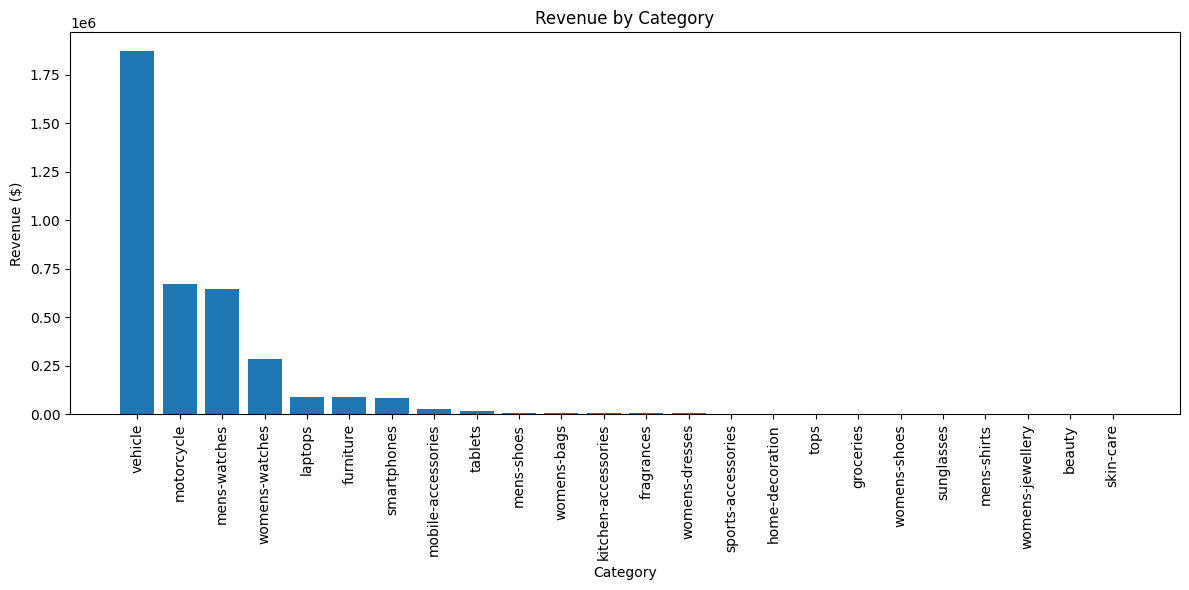

In [83]:
revenue_category = (
    final_df.groupby("category")["product_total"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

plt.bar(
    revenue_category.index,
    revenue_category.values
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Top 10 Selling Products

- This chart displays the top 10 products based on total quantity sold.
- It helps identify the best-selling products.
- These products can be prioritized for inventory management and promotional campaigns.

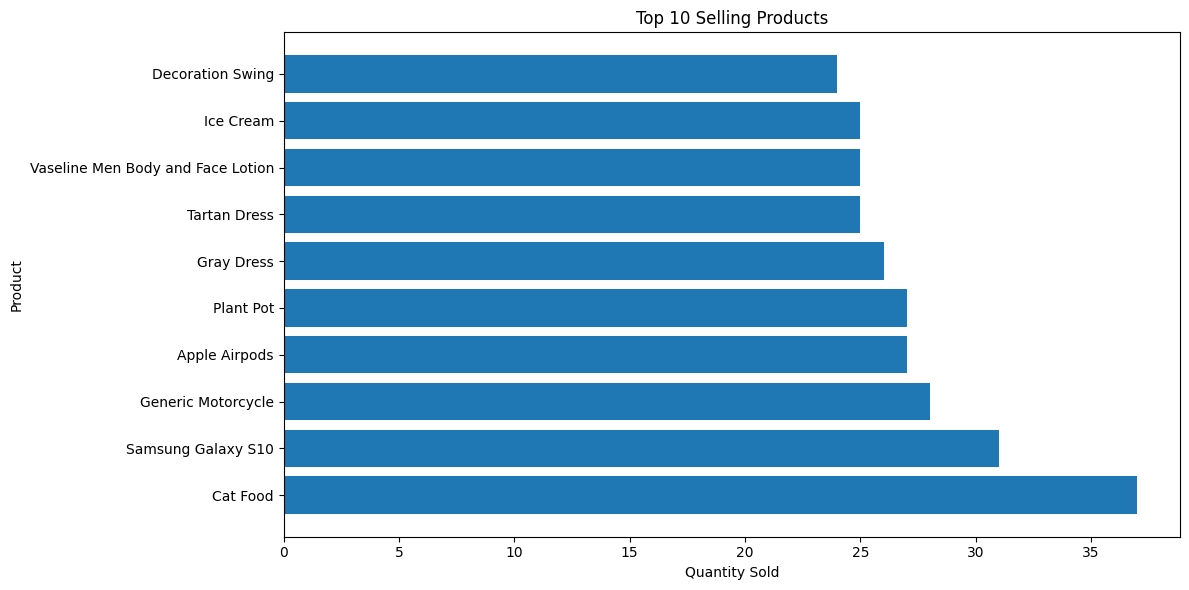

In [84]:
top_products = (
    final_df.groupby("product_name")["product_quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

### Revenue by Age

- Shows revenue generated by each age group.
- Helps identify the most valuable customer age segment.
- Useful for targeted marketing and customer analysis.

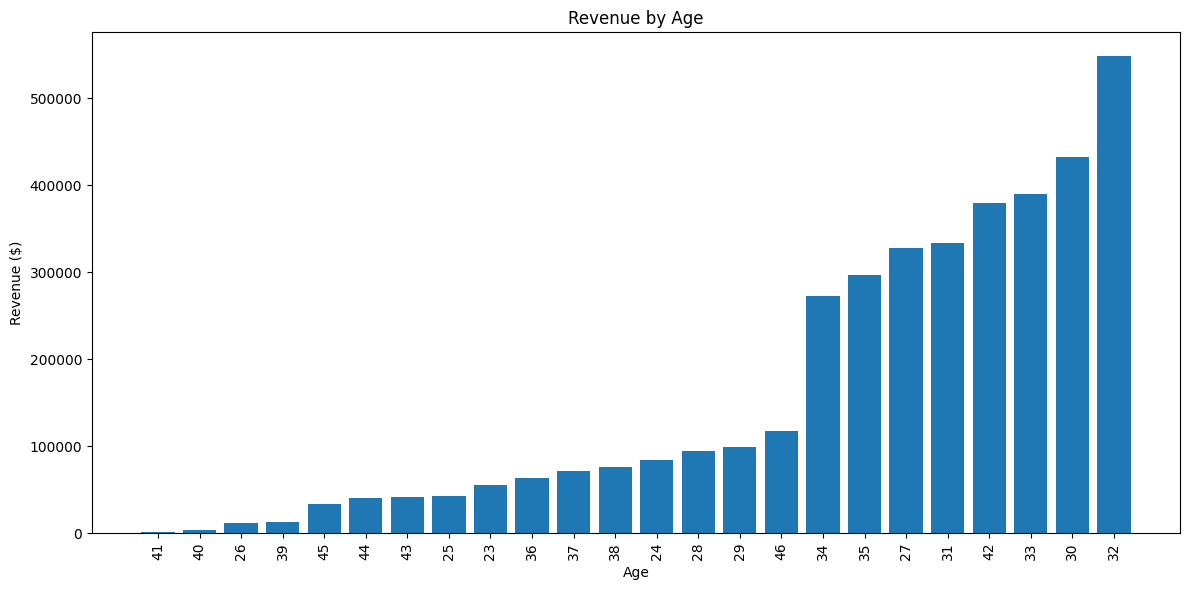

In [85]:
age_spending = (
    final_df.groupby("age")["product_total"]
    .sum()
    .sort_values()
)

plt.figure(figsize=(12,6))

plt.bar(age_spending.index.astype(str), age_spending.values)

plt.title("Revenue by Age")
plt.xlabel("Age")
plt.ylabel("Revenue ($)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

### Correlation Heatmap

- Shows the relationship between numerical variables.
- Helps identify positive and negative correlations.
- Useful for understanding factors that influence sales performance.

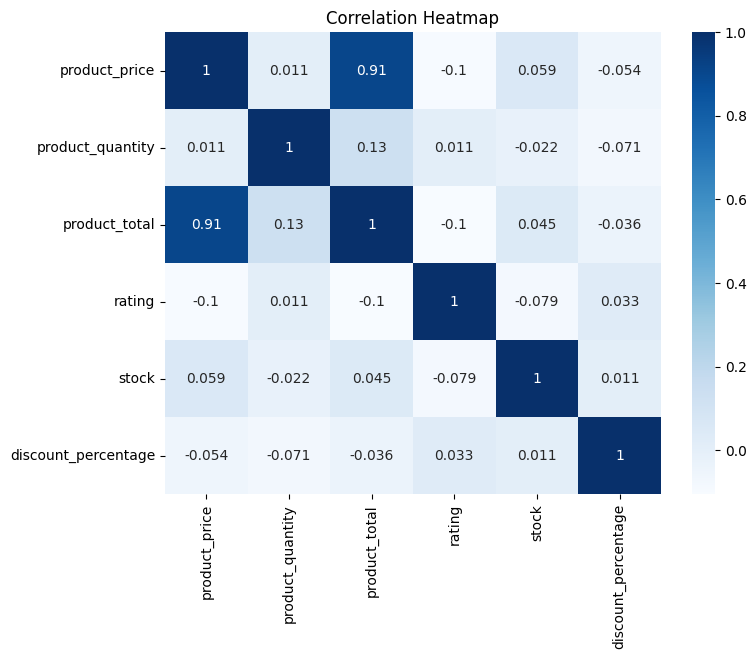

In [86]:
 

corr = final_df[
    [
        "product_price",
        "product_quantity",
        "product_total",
        "rating",
        "stock",
        "discount_percentage"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

In [87]:
# Revenue by Category
revenue_category

category
vehicle                1875999.40
motorcycle              669999.16
mens-watches            644849.28
womens-watches          282859.55
laptops                  91899.44
furniture                88399.27
smartphones              82348.23
mobile-accessories       29656.02
tablets                  16849.60
mens-shoes                8589.25
womens-bags               6749.38
kitchen-accessories       6304.39
fragrances                5649.36
womens-dresses            4859.51
sports-accessories        4240.31
home-decoration           3034.19
tops                      2589.23
groceries                 2064.26
womens-shoes              1759.52
sunglasses                1572.43
mens-shirts               1537.43
womens-jewellery          1024.58
beauty                     938.30
skin-care                  506.54
Name: product_total, dtype: float64

In [88]:
# Top Products
top_products

product_name
Cat Food                             37
Samsung Galaxy S10                   31
Generic Motorcycle                   28
Apple Airpods                        27
Plant Pot                            27
Gray Dress                           26
Tartan Dress                         25
Vaseline Men Body and Face Lotion    25
Ice Cream                            25
Decoration Swing                     24
Name: product_quantity, dtype: int64

In [89]:
# Top Customers
users_df["age"].value_counts()

age
30    19
29    17
27    17
28    16
32    16
34    15
31    14
35    12
33    11
37     9
42     8
36     7
26     7
43     5
46     5
38     5
45     5
39     4
25     4
40     4
44     4
41     2
23     1
24     1
Name: count, dtype: int64

In [90]:
final_df["gender"].value_counts()

gender
male      413
female    387
Name: count, dtype: int64

In [91]:
final_df["rating"].value_counts()

rating
4.05    21
4.77    15
3.62    15
3.18    15
3.70    14
        ..
3.17     1
3.08     1
3.52     1
4.73     1
3.87     1
Name: count, Length: 135, dtype: int64

In [95]:
top_users

NameError: name 'top_users' is not defined

In [93]:
products_df["brand"].value_counts().head(10)

brand
Apple               14
Rolex                6
Samsung              5
Fashion Shades       4
Oppo                 3
Realme               3
Vivo                 3
Dodge                3
Calvin Klein         2
Annibale Colombo     2
Name: count, dtype: int64

In [94]:
products_df.to_csv("products.csv", index=False)  # fst dataset
users_df.to_csv("users.csv", index=False)        # sec dataset
carts_df.to_csv("carts.csv", index=False)        # third dataset
final_df.to_csv("final_df.csv", index=False)     # after merge all 3

# 📊 Business Insights

## 1. Revenue by Category
- The **Vehicle** category generated the highest revenue of **$1,875,999.40**, making it the strongest contributor to overall sales.
- The **Motorcycle** category ranked second with **$669,999.16**, followed by **Men's Watches** at **$644,849.28**.
- Categories such as **Beauty ($938.30)** and **Skin Care ($506.54)** generated the lowest revenue, indicating lower customer demand.

---

## 2. Top Selling Products
- **Cat Food** was the best-selling product with **37 units sold**.
- **Samsung Galaxy S10 (31 units)** and **Generic Motorcycle (28 units)** were also among the top-selling products.
- Daily-use products and electronic gadgets showed consistently high purchase volumes.

---

## 3. Brand Analysis
- **Apple** had the highest number of products (**14**) available in the catalog.
- **Rolex (6 products)** and **Samsung (5 products)** were also among the leading brands.
- Popular brands dominated product listings, indicating strong brand representation in the marketplace.

---

## 4. Customer Spending Analysis
- **Addison Wright** was the highest spending customer with a total purchase value of **$186,110.85**.
- The remaining top customers each spent over **$128,000**, showing that a small group of customers contributed significantly to total revenue.
- High-value customers should be targeted with loyalty rewards and personalized offers.

---

## 5. Customer Demographics
- The dataset contains a balanced customer base with **413 male** and **387 female** purchase records.
- Sales are distributed almost equally across both genders, indicating broad customer reach.

---

## 6. Age Group Analysis
- Customers aged **30 years** placed the highest number of purchases (**19 orders**).
- The **27–35 age group** represents the majority of customers, making them the primary target audience.
- Customers below **25 years** contributed relatively fewer purchases.

---

## 7. Product Rating Analysis
- **Amazon Echo Plus** was the highest-rated product with a rating of **4.99/5**.
- **iPhone X** received the lowest rating of **2.51/5**, suggesting lower customer satisfaction compared to other products.
- Most product ratings were between **3.5 and 4.8**, indicating generally positive customer feedback.

---

## 8. Product Performance
- Expensive categories such as **Vehicles** and **Motorcycles** generated significantly higher revenue despite selling fewer units than some low-cost products.
- In contrast, products like **Cat Food** achieved high sales volume but contributed less revenue due to their lower price.

---

## 9. Revenue Distribution
- A large share of total revenue was generated by premium product categories including **Vehicles**, **Motorcycles**, and **Luxury Watches**.
- Lower-priced categories mainly contributed through higher sales volume rather than higher revenue.

---

## 10. Business Recommendations
- Increase inventory and marketing efforts for **Vehicle**, **Motorcycle**, and **Luxury Watch** categories to maximize revenue.
- Promote best-selling products such as **Cat Food** and **Samsung Galaxy S10** through bundled offers and cross-selling strategies.
- Review customer feedback for **iPhone X** to identify quality or satisfaction issues.
- Develop loyalty programs targeting top-spending customers to improve customer retention.
- Focus marketing campaigns on customers aged **27–35 years**, as they represent the most active purchasing segment.

---

## 11. Pricing Strategy
- Premium-priced products generated the highest revenue, while affordable products achieved higher sales volume.
- Maintaining a balanced portfolio of premium and budget-friendly products can help maximize both revenue and customer reach.

---

## 12. Inventory Strategy
- High-demand products should be monitored regularly to prevent stock shortages.
- Low-performing categories can be supported through promotional campaigns or seasonal discounts to improve sales.